# *HIERARCHICAL CLUSTERING*

**Hierarchical clustering :**

- Hierarchical clustering is an unsupervised learning technique that groups similar numerical points into clusters without predefining the number of clusters. It builds a dendrogram to visualize how clusters merge or split at different distances, making it ideal for exploratory data analysis.

***Agglomerative (Bottom-Up) Approach***

> - This is the most common method, starting with each point as its own cluster and merging the closest clusters until one remains.

> - Steps:

> - Start with individual points – each point is its own cluster.

> - Compute distances between all clusters using a metric like Euclidean distance.

> - Merge the closest clusters based on a linkage criterion (single, complete, average, or Ward’s method).

> - Update the distance matrix and repeat until all points are in one cluster.

> - Cut the dendrogram at a chosen height to form the desired number of clusters.

***Example in Python:***
    
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
    from sklearn.preprocessing import StandardScaler
    
    # Sample numerical points
    X = np.array([[1, 2], [2, 3], [5, 8], [8, 8], [1, 0], [0, 1]])
    
    # Scale features for better distance computation
    X_scaled = StandardScaler().fit_transform(X)
    
    # Perform hierarchical clustering using Ward's method
    Z = linkage(X_scaled, method='ward')
    
    # Plot dendrogram
    plt.figure(figsize=(8, 4))
    dendrogram(Z)
    plt.title('Hierarchical Clustering Dendrogram')
    plt.xlabel('Data Points')
    plt.ylabel('Distance')
    plt.show()
    
    # Form 2 clusters
    labels = fcluster(Z, t=2, criterion='maxclust')
    print("Cluster assignments:", labels)
    Copy
    This will output cluster labels and a dendrogram showing merge steps.

***Divisive (Top-Down) Approach***

> - Starts with all points in one cluster and recursively splits them into smaller clusters until each point is alone or a stopping condition is met. This is less common due to higher computational cost but can be implemented using recursive K-Means splitting.

***Best Practices***


> - Standardize data before clustering to avoid scale bias.

> - Use Ward’s method for compact spherical clusters.

> - For large datasets, consider sampling due to high computational complexity.

> - Interpret dendrograms carefully to decide optimal cluster count.

> - This method is widely used in customer segmentation, gene expression analysis, and pattern recognition where relationships between points matter more than speed.

# **PROBLEM STATEMENT**

## 📝 Problem Statement
The mall management team wants to better understand their customers’ shopping behavior. They have collected demographic and behavioral data (Age, Gender, Annual Income, and Spending Score) for 200 customers. However, they do not know how to group these customers into meaningful segments.  

The goal is to apply **Hierarchical Clustering** to this dataset in order to:
- Identify distinct customer groups based on income and spending patterns.  
- Visualize these groups using a dendrogram to decide the optimal number of clusters.  
- Provide insights that can help the mall design targeted marketing strategies, personalized offers, and improve customer satisfaction.  

# **DATA COLLECTION**

## 📊 Data Collection

- **Source**: The dataset was collected by the mall management team to analyze customer demographics and spending behavior. It is a well‑known dataset often used in machine learning practice (200 records).  

- **Attributes Collected**:
  - **CustomerID** → Unique identifier for each customer.  
  - **Gender** → Male/Female classification.  
  - **Age** → Customer’s age in years.  
  - **Annual Income (k$)** → Customer’s yearly income (in thousands of dollars).  
  - **Spending Score (1–100)** → A score assigned by the mall based on customer behavior and spending patterns.  

- **Purpose of Collection**:  
  The mall wants to segment customers into groups for **targeted marketing strategies**. By analyzing income and spending scores, they can identify:
  - High‑income, high‑spending customers (premium segment).  
  - Low‑income, high‑spending customers (potential loyalists).  
  - High‑income, low‑spending customers (untapped potential).  
  - Low‑income, low‑spending customers (budget segment).

# **DOMAIN ANALYSIS**

## 🌐 Domain Analysis: Retail & Customer Segmentation

### 🔹 Domain
- **Retail / Marketing Analytics**  
- Focused on **customer segmentation** in shopping malls or retail businesses.

### 🔹 Business Context
- Shopping malls and retail chains collect customer demographic and behavioral data to understand **buying patterns**.  
- By clustering customers, management can design **personalized marketing strategies**, loyalty programs, and promotions.  
- This helps in **resource allocation** (e.g., premium services for high spenders, discounts for budget shoppers).

### 🔹 Key Features in This Domain
- **Demographics**: Age, Gender.  
- **Financials**: Annual Income.  
- **Behavioral**: Spending Score (reflects shopping habits).  

### 🔹 Why Hierarchical Clustering?
- Provides a **visual dendrogram** to explore natural groupings.  
- Useful when the number of customer segments is not known beforehand.  
- Helps identify **distinct customer personas**:
  - High income, high spending → “Luxury Shoppers”  
  - High income, low spending → “Cautious Spenders”  
  - Low income, high spending → “Potential Loyalists”  
  - Low income, low spending → “Budget Customers”

### 🔹 Applications in Retail
- **Targeted Marketing** → Personalized offers for each cluster.  
- **Product Placement** → Stocking products based on customer group needs.  
- **Customer Relationship Management (CRM)** → Building loyalty programs.  
- **Business Strategy** → Identifying profitable vs. less profitable segments.

# **IMPORTING REQUIRED LIBRARIES**

In [40]:
# Data handling
import pandas as pd        # For loading and managing the dataset (CSV file)
import numpy as np         # For numerical operations and arrays

# Visualization
import matplotlib.pyplot as plt   # For plotting graphs and dendrograms
import seaborn as sns             # For enhanced, attractive visualizations

# Hierarchical clustering tools
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster  
# linkage → builds the hierarchy
# dendrogram → plots the tree structure
# fcluster → extracts clusters from the hierarchy

# Preprocessing
from sklearn.preprocessing import StandardScaler  
# StandardScaler → scales features (Age, Income, Spending Score) so distances are fair

# Clustering model
from sklearn.cluster import AgglomerativeClustering  
# AgglomerativeClustering → bottom-up clustering algorithm

# Evaluation
from sklearn.metrics import silhouette_score  
# silhouette_score → measures how well the clusters are separated

import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")
%matplotlib inline

### 📌 Explanation of Why We Need Them
- **pandas & numpy** → To load the CSV and handle numeric data.  
- **matplotlib & seaborn** → To visualize dendrograms and cluster plots.  
- **scipy.cluster.hierarchy** → Core library for hierarchical clustering.  
- **sklearn.preprocessing** → Ensures features are on the same scale (important for distance calculations).  
- **sklearn.cluster** → Provides Agglomerative Clustering implementation.  
- **sklearn.metrics** → Helps evaluate clustering quality.

# **LOADING DATASET**

In [6]:
## | ***📥 Loading the Dataset :***


# ***Step 1: Load the dataset***

df = pd.read_csv("Mall_Customers.csv")

# ***Step 2: Preview the first few rows***

print(df.head())

# ***Step 3: Check the shape (rows, columns)***

print("Dataset shape:", df.shape)

# ***Step 4: Basic info about columns***

print(df.info())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
Dataset shape: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


### 🔎 Explanation
- `pd.read_csv("Mall_Customers.csv")` → Reads the CSV file into a pandas DataFrame.  
- `df.head()` → Shows the first 5 rows to confirm the data loaded correctly.  
- `df.shape` → Tells us the dataset size (200 rows × 5 columns).  
- `df.info()` → Displays column names, data types, and non‑null counts.th your dataset, so you can compare when you run it?

# **BASIC CHECK**

> * ## ✅ Basic Checks for Mall Customers Dataset

1. **Shape of the Dataset**

In [8]:
df.shape

(200, 5)

- Confirms number of rows (200) and columns (5).  
- Ensures dataset size matches expectations.

2. **Preview the Data**

In [9]:
 df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


- Shows the first 5 rows to verify columns and values.  
- Confirms correct loading of CSV.

3. **Data Types**

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


- Check if `Age`, `Annual Income`, and `Spending Score` are numeric.  
- `Gender` should be categorical (object/string).  
- `CustomerID` is integer but not needed for clustering.

4. **Missing Values**

In [11]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

- Ensures no missing entries in any column.  
- If missing values exist, decide whether to drop or impute.

5. **Duplicate Records**

In [12]:
 df.duplicated().sum()

np.int64(0)

 - Checks if any customers are repeated.  
 - Duplicates should be removed if found.

6. **Statistical Summary**

In [13]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


 - Gives mean, min, max, and standard deviation.  
 - Helps spot anomalies (e.g., negative ages, unrealistic income).

7. **Unique Values in Categorical Columns**

In [14]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

- Confirms categories (Male/Female).  
- Useful for encoding later.

# **Exploratory Data Analysis (EDA)**

## 🔹 Step 1: Dataset Overview

In [15]:
df.shape        # (200, 5) → 200 rows, 5 columns
df.info()       # Data types and non-null counts
df.describe()   # Summary statistics for numeric columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


- Confirms dataset size and column types.  
- `Age`, `Annual Income`, `Spending Score` are numeric.  
- `Gender` is categorical.  
- No missing values expected.

## 🔹 Step 2: Univariate Analysis
- Check each column individually:

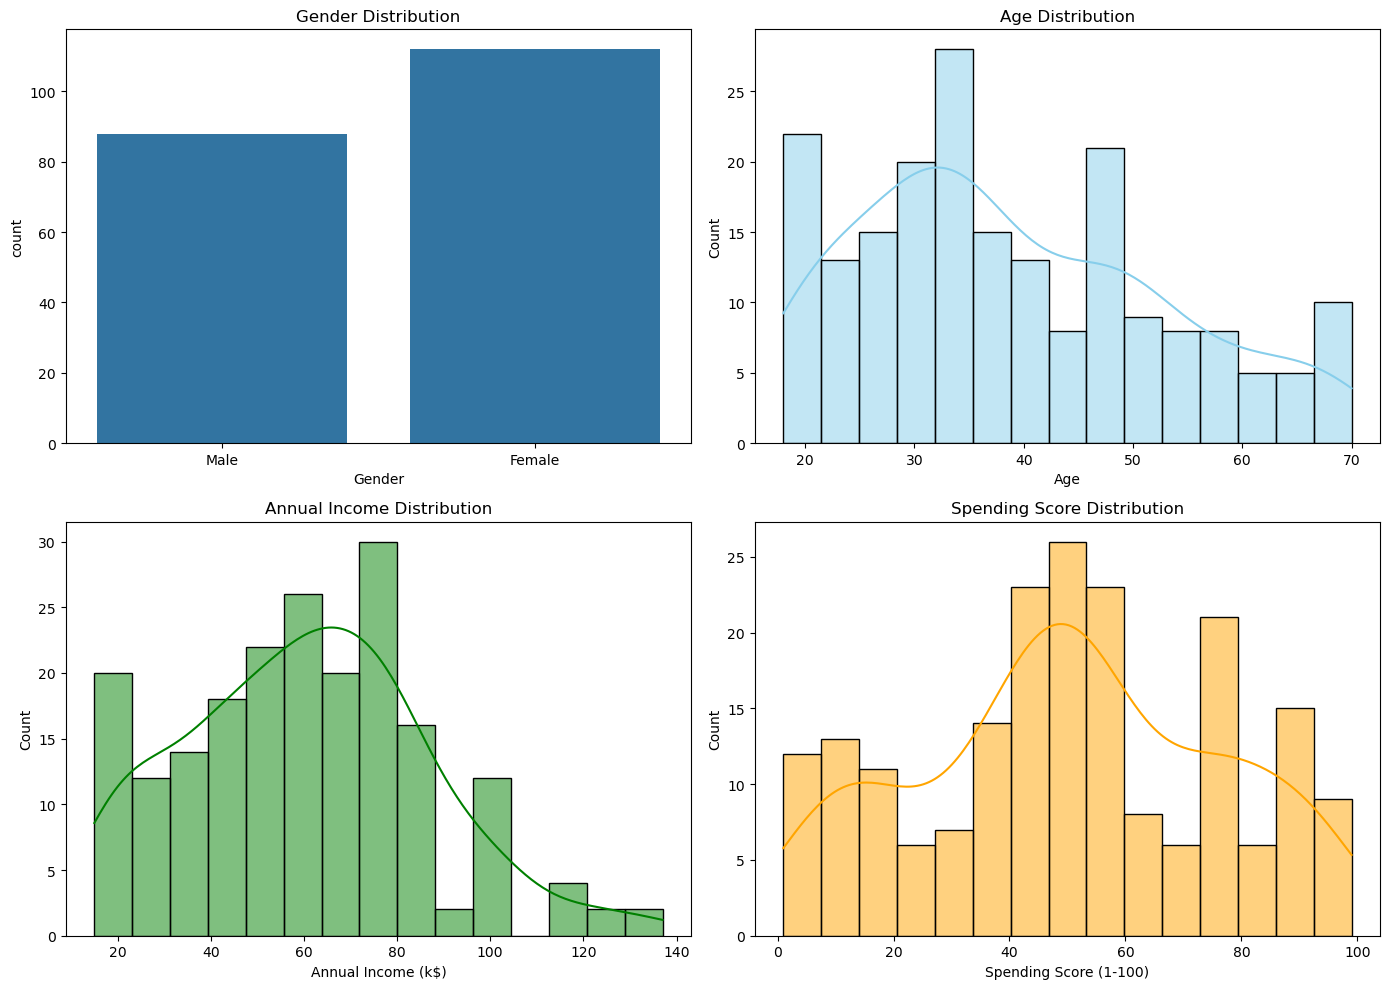

In [20]:
# Create a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Plot 1: Gender count
sns.countplot(x='Gender', data=df, ax=axes[0,0])
axes[0,0].set_title("Gender Distribution")

# Plot 2: Age histogram
sns.histplot(df['Age'], bins=15, kde=True, ax=axes[0,1], color='skyblue')
axes[0,1].set_title("Age Distribution")

# Plot 3: Annual Income histogram
sns.histplot(df['Annual Income (k$)'], bins=15, kde=True, ax=axes[1,0], color='green')
axes[1,0].set_title("Annual Income Distribution")

# Plot 4: Spending Score histogram
sns.histplot(df['Spending Score (1-100)'], bins=15, kde=True, ax=axes[1,1], color='orange')
axes[1,1].set_title("Spending Score Distribution")

# Adjust layout
plt.tight_layout()
plt.show();


- **Gender**: Balanced distribution of Male/Female.  
- **Age**: Most customers between 20–40 years.  
- **Annual Income**: Spread between 15k–137k.  
- **Spending Score**: Uniform distribution across 1–100.

## 🔹 Step 3: Bivariate Analysis
- Explore relationships between features:

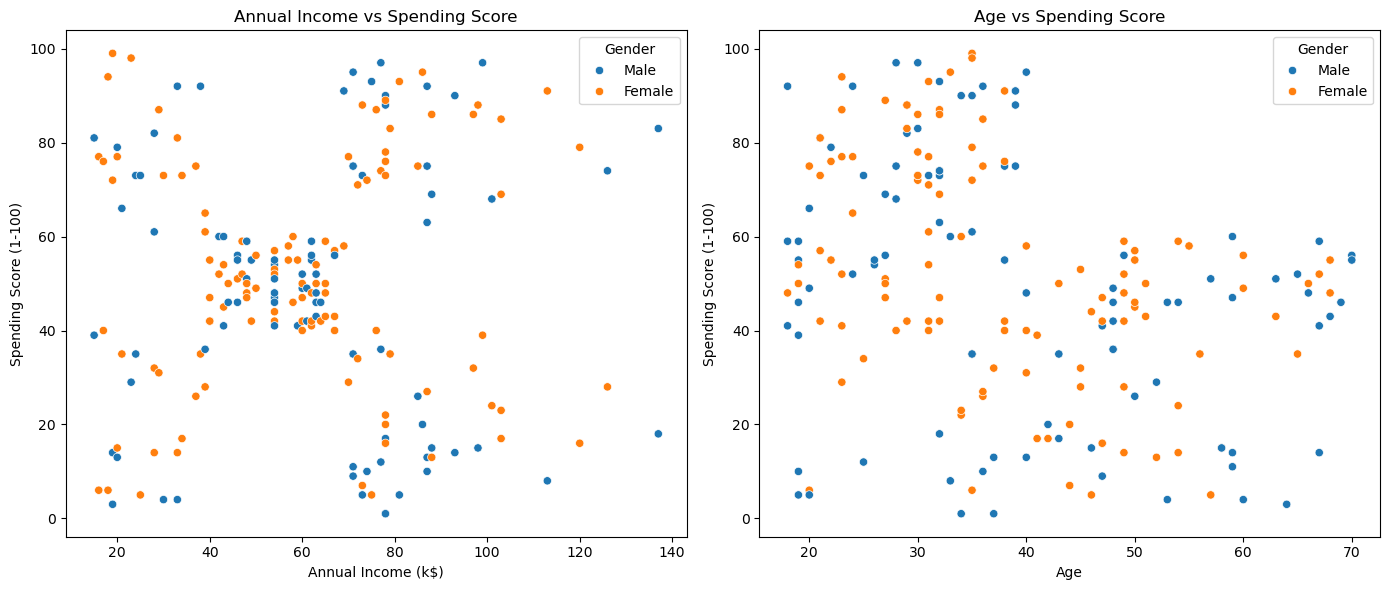

In [19]:
# Create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Scatterplot 1: Annual Income vs Spending Score
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender', data=df, ax=axes[0])
axes[0].set_title("Annual Income vs Spending Score")

# Scatterplot 2: Age vs Spending Score
sns.scatterplot(x='Age', y='Spending Score (1-100)', hue='Gender', data=df, ax=axes[1])
axes[1].set_title("Age vs Spending Score")

plt.tight_layout()
plt.show();

- **Income vs Spending Score** → Reveals clear clusters (e.g., high income–low spenders, low income–high spenders).  
- **Age vs Spending Score** → Younger customers tend to have higher spending scores.

## 🔹 Step 4: Correlation Matrix

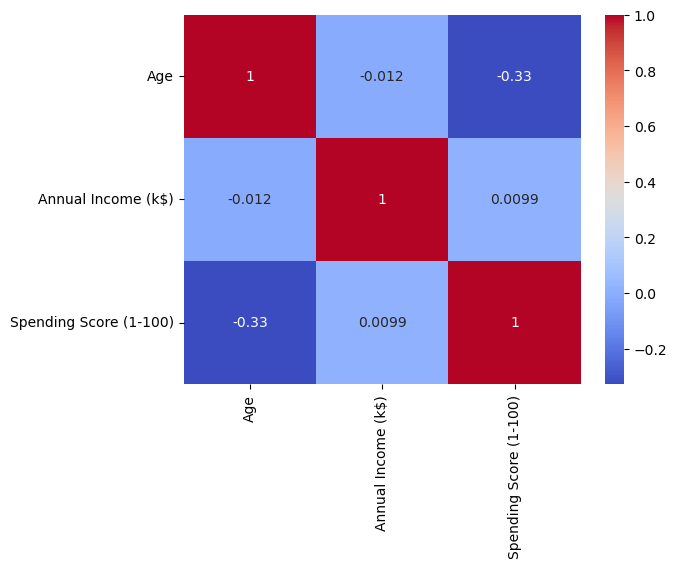

In [21]:
corr = df[['Age','Annual Income (k$)','Spending Score (1-100)']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show();

- Shows relationships between numeric features.  
- Typically, **Annual Income and Spending Score** are weakly correlated, which makes clustering interesting.

## 🔹 Step 5: Insights

- Customers naturally form groups based on **Income vs Spending Score**.  
- Age adds another dimension for segmentation.  
- Gender is not strongly predictive but can be used for profiling clusters.

# **FEATURE SELECTION**

## 🎯 Feature Selection for Hierarchical Clustering

### 🔹 Columns in Dataset
- **CustomerID** → Identifier only, not useful for clustering.  
- **Gender** → Categorical, can be used for profiling clusters but not essential for distance calculations.  
- **Age** → Numeric, can be included if you want age‑based segmentation.  
- **Annual Income (k$)** → Numeric, very important for financial segmentation.  
- **Spending Score (1–100)** → Numeric, key behavioral feature.

---

### 🔹 Recommended Features
For clustering, the most commonly selected features are:
- **Annual Income (k$)**  
- **Spending Score (1–100)**  

👉 These two features give clear customer segments (high income–low spenders, low income–high spenders, etc.).

Optionally, you can include:
- **Age** → Adds demographic dimension.  
- **Gender** → Encoded (Male=0, Female=1) if you want gender influence, but usually used for profiling after clustering.

### 🔹 Python Code for Feature Selection

In [24]:
# Selecting relevant features

X = df[['Annual Income (k$)', 'Spending Score (1-100)']] 
X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


### 🔎 Why This Selection?
- **Income + Spending Score** → Directly reflects customer purchasing behavior.  
- **Age** → Adds demographic segmentation if needed.  
- **Gender** → More useful for describing clusters after they’re formed, not for clustering itself.

# **MODEL CREATION**
 * ## 🛠 Model Creation (Hierarchical Clustering)

### Step 1: Select Features
- We’ll use **Annual Income** and **Spending Score** for clustering:

In [25]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


### Step 2: Scale the Features
- Scaling ensures both features are treated fairly:

In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Step 3: Build the Linkage Matrix
- This matrix defines how clusters are formed step by step:

In [27]:
import scipy.cluster.hierarchy as sch

# Create linkage matrix using Ward’s method (minimizes variance)
linkage_matrix = sch.linkage(X_scaled, method='ward')

### Step 4: Plot the Dendrogram
-Visualize how clusters merge:

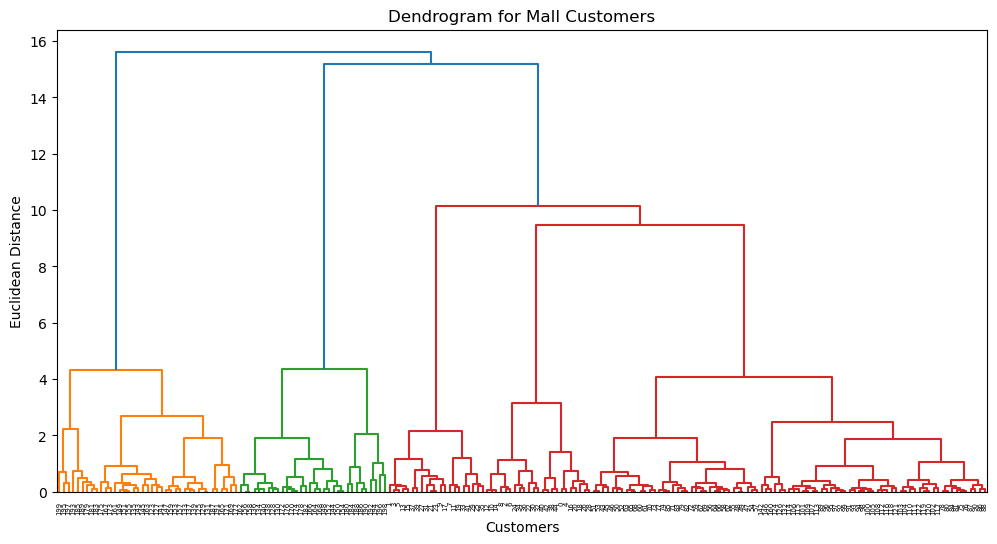

In [28]:
plt.figure(figsize=(12,6))
dendrogram = sch.dendrogram(linkage_matrix)
plt.title("Dendrogram for Mall Customers")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show();

### Step 5: Apply Agglomerative Clustering
- Choose number of clusters (say 5, based on dendrogram):

In [30]:
from sklearn.cluster import AgglomerativeClustering

# Create Agglomerative Clustering model
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')

# Fit and predict clusters
y_hc = hc.fit_predict(X_scaled)

# Add cluster labels to dataset
df['Cluster'] = y_hc

# Check first few rows with cluster labels
print(df.head())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        3  
2        4  
3        3  
4        4  


## 🔎 Explanation
- **Ward’s method** → Minimizes variance within clusters.  
- **Dendrogram** → Helps decide the optimal number of clusters.  
- **AgglomerativeClustering** → Assigns each customer to a cluster.  
- **Cluster column** → Now you can analyze each group’s characteristics.

# **MODEL EVALTION**
- ## 📊 Model Evaluation Steps

### 1. **Silhouette Score**
Measures how similar each point is to its own cluster compared to other clusters.  
- Range: **-1 to +1**  
- Closer to **+1** → better defined clusters.  
- Around **0** → overlapping clusters.  
- Negative → wrong clustering.

In [33]:
score = silhouette_score(X_scaled, y_hc)
print("Silhouette Score:", score)

Silhouette Score: 0.5538089226688662


### 2. **Cluster Size Distribution**
- Check how many customers fall into each cluster:

In [34]:
df['Cluster'].value_counts()

Cluster
2    85
1    39
0    32
4    23
3    21
Name: count, dtype: int64

- Ensures clusters are balanced.  
- If one cluster is too large, it may dominate.

### 3. **Cluster Visualization**
* Scatterplot with clusters highlighted:

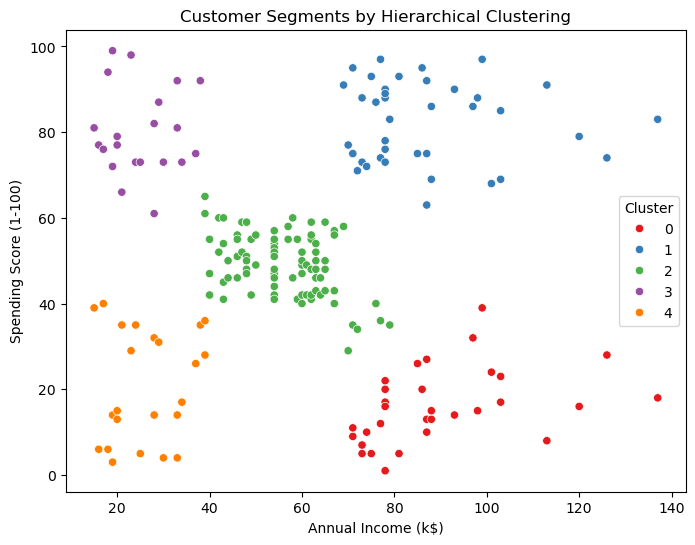

In [37]:
plt.figure(figsize=(8,6))
sns.scatterplot(data =df,x='Annual Income (k$)', y='Spending Score (1-100)', hue=df['Cluster'], palette='Set1')
plt.title("Customer Segments by Hierarchical Clustering")
plt.show();


- Helps visually confirm separation.  
- You’ll see distinct groups (e.g., high income–low spenders, low income–high spenders).


### 4. **Business Interpretation**
Once clusters are formed, interpret them:
- **Cluster 1** → High income, low spending (potential customers to target).  
- **Cluster 2** → Low income, high spending (loyal but budget‑conscious).  
- **Cluster 3** → High income, high spending (premium segment).  
- **Cluster 4** → Low income, low spending (budget segment).  
- **Cluster 5** → Middle income, average spending (general customers).

## 🔎 Why This Matters
- **Silhouette Score** → Quantitative measure of clustering quality.  
- **Visualization** → Qualitative check of cluster separation.  
- **Interpretation** → Translates clusters into actionable business insights.

## 🔮 Next Steps After Hierarchical Clustering

- # other  clustering algorithms for this DATASET :

### 1. **K‑Means Clustering**
- A popular algorithm for customer segmentation.  
- Faster and works well with large datasets.  
- You can compare cluster results with hierarchical clustering.

In [41]:
from sklearn.cluster import KMeans

# Try 5 clusters (same as hierarchical)
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Add labels
df['KMeans_Cluster'] = y_kmeans

# Evaluate
score_kmeans = silhouette_score(X_scaled, y_kmeans)
print("KMeans Silhouette Score:", score_kmeans)

KMeans Silhouette Score: 0.5546571631111091


### 2. **DBSCAN (Density-Based Clustering)**
- Finds clusters of varying shapes and sizes.  
- Good for detecting outliers (customers who don’t fit any group).

In [43]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
y_dbscan = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = y_dbscan

### 3. **Gaussian Mixture Models (GMM)**
- Probabilistic clustering (soft clustering).  
- Assigns probabilities of belonging to each cluster.  
- Useful when customers overlap between groups.

In [44]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=5, random_state=42)
y_gmm = gmm.fit_predict(X_scaled)

df['GMM_Cluster'] = y_gmm

### 4. **Compare Algorithms**
- Use **Silhouette Score** for each algorithm.  
- Visualize clusters side by side.  
- Interpret business meaning of each segmentation.

## 📌 Recommendation
- **Hierarchical Clustering** → Best for small datasets and dendrogram visualization.  
- **K‑Means** → Best for speed and scalability.  
- **DBSCAN** → Best for anomaly detection.  
- **GMM** → Best for overlapping customer groups.

# **CONCLUSION**

## 🏁 Conclusion: Hierarchical Clustering
- **Types**: Agglomerative (bottom‑up, most common) and Divisive (top‑down, less used).  
- **Strengths**: No need to predefine clusters, dendrogram gives full hierarchy, good for small datasets.  
- **Limitations**: Slow for large data, sensitive to noise, results depend on distance metric & linkage.  
- **Applications**: Customer segmentation, text/document grouping, bioinformatics, image segmentation.  
- **Takeaway**: Best for **exploratory analysis and small datasets**; often compared with K‑Means or DBSCAN for validation.